In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/02_nav_history.csv"
)

nav['date'] = pd.to_datetime(nav['date'])

print(nav.shape)
nav.head()

In [2]:
nav = nav.sort_values(
    ['amfi_code', 'date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


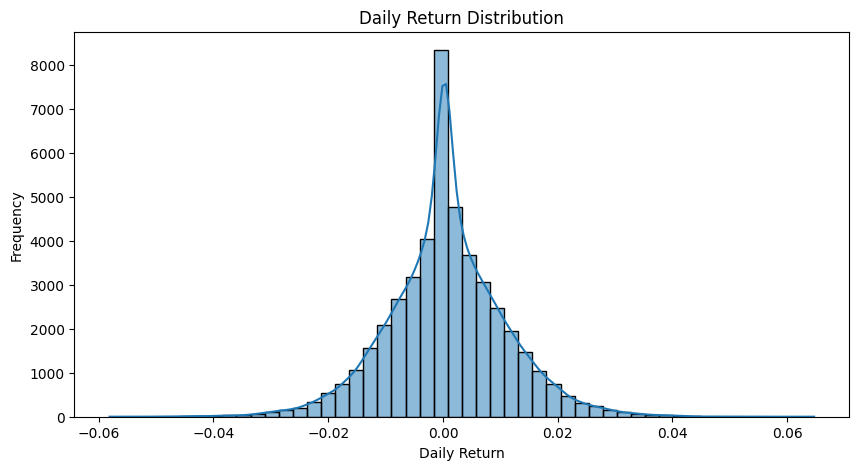

In [3]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav['daily_return'].dropna(),
    bins=50,
    kde=True
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [4]:
print(
    nav['daily_return'].describe()
)

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [5]:
def calculate_cagr(start_value, end_value, years):
    return (end_value / start_value) ** (1 / years) - 1

In [6]:
nav = nav.sort_values(['amfi_code', 'date'])

In [7]:
cagr_df = nav.groupby('amfi_code').agg(
    start_nav=('nav', 'first'),
    end_nav=('nav', 'last'),
    start_date=('date', 'first'),
    end_date=('date', 'last')
).reset_index()

cagr_df.head()

,amfi_code,start_nav,end_nav,start_date,end_date
0,100016,520.4608,583.6113,2022-01-03,2026-05-29
1,100025,26.3169,31.8843,2022-01-03,2026-05-29
2,100033,107.3758,342.0072,2022-01-03,2026-05-29
3,101206,305.0996,773.2939,2022-01-03,2026-05-29
4,101207,38.5736,53.9836,2022-01-03,2026-05-29


In [11]:
cagr_df['years'] = (
    (cagr_df['end_date'] - cagr_df['start_date']).dt.days / 365
)


In [9]:
cagr_df['cagr'] = calculate_cagr(
    cagr_df['start_nav'],
    cagr_df['end_nav'],
    cagr_df['years']
)

cagr_df[['amfi_code', 'cagr']].head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [12]:
risk_free_rate = 0.065  # 6.5%

sharpe_df = nav.groupby('amfi_code')['daily_return'].agg(['mean','std']).reset_index()

sharpe_df['sharpe'] = (
    (sharpe_df['mean'] - risk_free_rate/252) /
    sharpe_df['std']
) * np.sqrt(252)

sharpe_df.head()

,amfi_code,mean,std,sharpe
0,100016,0.000142,0.009164,-0.201517
1,100025,0.000170,0.002460,-0.567095
2,100033,0.001080,0.011929,1.093699
3,101206,0.000852,0.009177,1.027213
4,101207,0.000424,0.016251,0.162661


In [13]:
final_df = cagr_df.merge(sharpe_df, on='amfi_code')

final_df['rank_cagr'] = final_df['cagr'].rank(ascending=False)
final_df['rank_sharpe'] = final_df['sharpe'].rank(ascending=False)

final_df.head()

,amfi_code,start_nav,end_nav,start_date,end_date,years,cagr,mean,std,sharpe,rank_cagr,rank_sharpe
0,100016,520.4608,583.6113,2022-01-03,2026-05-29,4.40274,0.026352,0.000142,0.009164,-0.201517,37.0,35.0
1,100025,26.3169,31.8843,2022-01-03,2026-05-29,4.40274,0.044551,0.000170,0.002460,-0.567095,36.0,39.0
2,100033,107.3758,342.0072,2022-01-03,2026-05-29,4.40274,0.300997,0.001080,0.011929,1.093699,7.0,7.0
3,101206,305.0996,773.2939,2022-01-03,2026-05-29,4.40274,0.235205,0.000852,0.009177,1.027213,12.0,9.0
4,101207,38.5736,53.9836,2022-01-03,2026-05-29,4.40274,0.079331,0.000424,0.016251,0.162661,27.0,28.0


In [14]:
downside = nav[nav['daily_return'] < 0]

sortino_df = nav.groupby('amfi_code')['daily_return'].agg(['mean']).reset_index()

down_std = downside.groupby('amfi_code')['daily_return'].std().reset_index()
down_std.columns = ['amfi_code', 'down_std']

sortino_df = sortino_df.merge(down_std, on='amfi_code', how='left')

risk_free = 0.065 / 252

sortino_df['sortino'] = (
    (sortino_df['mean'] - risk_free) / sortino_df['down_std']
) * np.sqrt(252)

sortino_df.head()

,amfi_code,mean,down_std,sortino
0,100016,0.000142,0.005261,-0.351047
1,100025,0.000170,0.001481,-0.941821
2,100033,0.001080,0.007133,1.829134
3,101206,0.000852,0.005238,1.799563
4,101207,0.000424,0.009555,0.276644


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/02_nav_history.csv"
)

nav['date'] = pd.to_datetime(nav['date'])

In [19]:
nav = nav.sort_values(['amfi_code','date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

In [20]:
cagr_df = nav.groupby('amfi_code').agg(
    start_nav=('nav','first'),
    end_nav=('nav','last')
).reset_index()

cagr_df['cagr'] = (cagr_df['end_nav']/cagr_df['start_nav'])**(1/4.4)-1

In [21]:
sharpe_df = nav.groupby('amfi_code')['daily_return'].agg(['mean','std']).reset_index()

sharpe_df['sharpe'] = (sharpe_df['mean']/sharpe_df['std'])*np.sqrt(252)

In [22]:
downside = nav[nav['daily_return'] < 0]

down_std = downside.groupby('amfi_code')['daily_return'].std().reset_index()
down_std.columns = ['amfi_code','down_std']

sortino_df = nav.groupby('amfi_code')['daily_return'].mean().reset_index()

sortino_df = sortino_df.merge(down_std,on='amfi_code',how='left')

sortino_df['sortino'] = (sortino_df['daily_return']/sortino_df['down_std'])*np.sqrt(252)

In [23]:
nav['cum_max'] = nav.groupby('amfi_code')['nav'].cummax()
nav['drawdown'] = nav['nav']/nav['cum_max'] - 1

max_dd = nav.groupby('amfi_code')['drawdown'].min().reset_index()
max_dd.columns = ['amfi_code','max_drawdown']

In [24]:
final_metrics = cagr_df.merge(sharpe_df,on='amfi_code')
final_metrics = final_metrics.merge(sortino_df[['amfi_code','sortino']],on='amfi_code')
final_metrics = final_metrics.merge(max_dd,on='amfi_code')

In [25]:
score_df = final_metrics.copy()

score_df['score'] = (
    (score_df['cagr'].rank(ascending=False)*0.30) +
    (score_df['sharpe'].rank(ascending=False)*0.25) +
    (score_df['sortino'].rank(ascending=False)*0.20) +
    (score_df['max_drawdown'].rank(ascending=True)*0.15)
)

score_df['score'] = 100 - (score_df['score']/score_df['score'].max()*100)

score_df.sort_values('score',ascending=False).head()

,amfi_code,start_nav,end_nav,cagr,mean,std,sharpe,sortino,max_drawdown,score
25,120505,135.8720,473.7640,0.328251,0.001161,0.012152,1.517047,2.608779,-0.181885,78.155340
36,148569,28.8620,97.7435,0.319472,0.001124,0.011134,1.602702,2.786282,-0.163967,76.213592
34,148567,70.2514,230.2708,0.309719,0.001074,0.008941,1.906241,3.139985,-0.112657,73.300971
30,120843,49.9131,163.2397,0.309053,0.001082,0.010008,1.715884,3.104586,-0.129740,73.300971
19,119551,54.3856,149.3216,0.258029,0.000917,0.008656,1.681289,2.978156,-0.150124,69.902913


In [26]:
nifty = nav.groupby('date')['daily_return'].mean().reset_index()
nifty.columns = ['date','nifty_return']

In [27]:
merged = nav.merge(nifty, on='date', how='left')
merged = merged.dropna()

In [28]:
from scipy import stats

alpha_beta_list = []

for code in merged['amfi_code'].unique():
    df = merged[merged['amfi_code'] == code]

    beta, alpha, r, p, se = stats.linregress(
        df['nifty_return'],
        df['daily_return']
    )

    alpha_beta_list.append([code, alpha*252, beta])

alpha_beta_df = pd.DataFrame(alpha_beta_list, columns=[
    'amfi_code','alpha','beta'
])

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,-0.089699,0.788441
1,100025,0.033199,0.060713
2,100033,0.114423,0.991590
3,101206,0.097443,0.737015
4,101207,-0.350741,2.878184


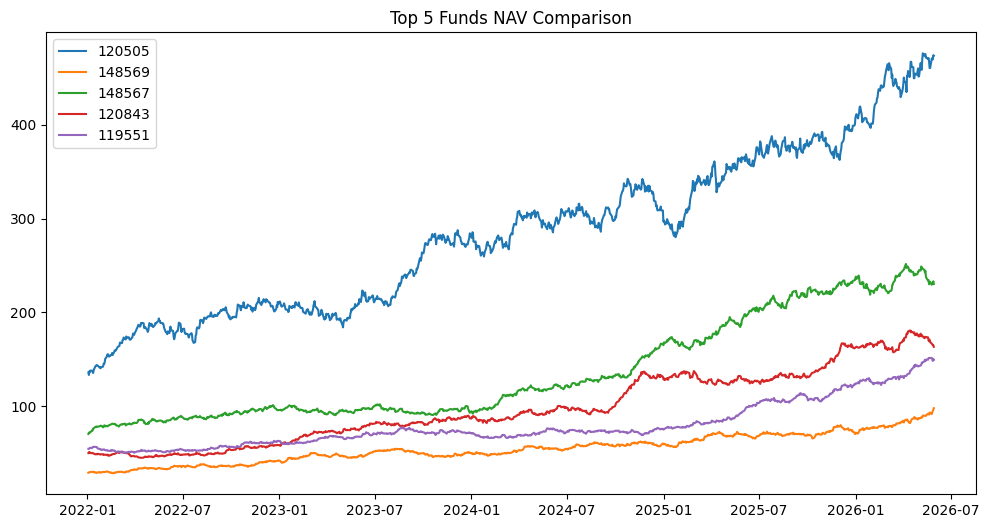

In [29]:
top5 = score_df.sort_values('score', ascending=False).head(5)

top5_data = nav[nav['amfi_code'].isin(top5['amfi_code'])]

plt.figure(figsize=(12,6))

for code in top5['amfi_code']:
    temp = top5_data[top5_data['amfi_code']==code]
    temp = temp.groupby('date')['nav'].mean()
    plt.plot(temp.index, temp.values, label=str(code))

plt.legend()
plt.title("Top 5 Funds NAV Comparison")
plt.show()

In [30]:
score_df.to_csv("../data/processed/fund_scorecard.csv", index=False)
alpha_beta_df.to_csv("../data/processed/alpha_beta.csv", index=False)

In [31]:
nifty = nav.groupby('date')['daily_return'].mean().reset_index()
nifty.columns = ['date', 'nifty_return']

In [32]:
merged = nav.merge(nifty, on='date', how='left')
merged = merged.dropna()

In [33]:
from scipy import stats
import pandas as pd

alpha_beta_list = []

for code in merged['amfi_code'].unique():
    df = merged[merged['amfi_code'] == code]

    beta, alpha, r, p, se = stats.linregress(
        df['nifty_return'],
        df['daily_return']
    )

    alpha_beta_list.append([
        code,
        alpha * 252,   # annualized alpha
        beta
    ])

alpha_beta_df = pd.DataFrame(
    alpha_beta_list,
    columns=['amfi_code', 'alpha', 'beta']
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,-0.089699,0.788441
1,100025,0.033199,0.060713
2,100033,0.114423,0.991590
3,101206,0.097443,0.737015
4,101207,-0.350741,2.878184


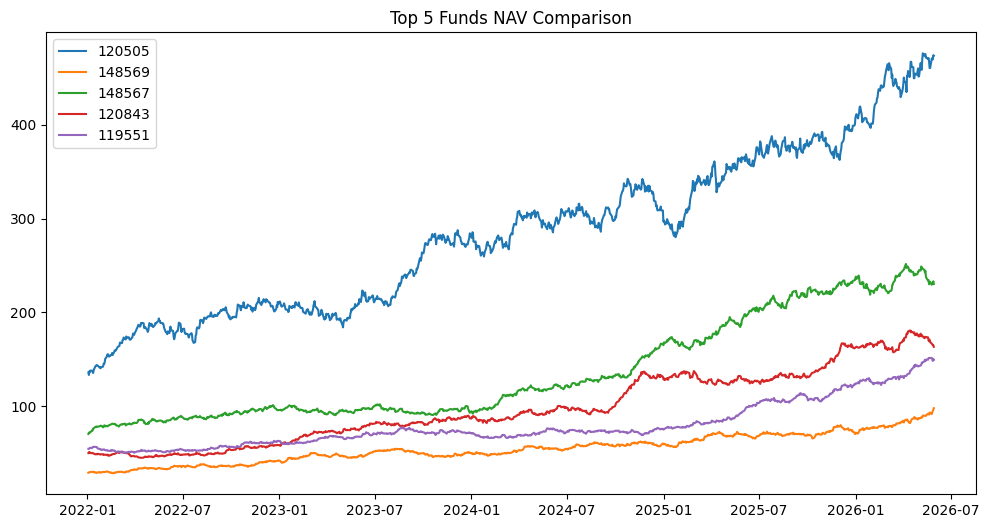

In [34]:
top5 = score_df.sort_values('score', ascending=False).head(5)

top5_nav = nav[nav['amfi_code'].isin(top5['amfi_code'])]

plt.figure(figsize=(12,6))

for code in top5['amfi_code']:
    temp = top5_nav[top5_nav['amfi_code'] == code]
    temp = temp.groupby('date')['nav'].mean()
    plt.plot(temp.index, temp.values, label=str(code))

plt.title("Top 5 Funds NAV Comparison")
plt.legend()
plt.show()

In [35]:
score_df.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [36]:
benchmark = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/10_benchmark_indices.csv"
)

benchmark['date'] = pd.to_datetime(benchmark['date'])

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [3]:
import pandas as pd

benchmark = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/10_benchmark_indices.csv"
)

print(benchmark.columns.tolist())
benchmark.head()

['date', 'index_name', 'close_value']


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [4]:
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [7]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [8]:
print(benchmark['index_name'].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [10]:
nifty100 = benchmark[
    benchmark['index_name'] == 'ACTUAL_NAME'
].copy()

In [11]:
nifty100 = benchmark[
    benchmark['index_name'] == 'ACTUAL_NAME'
].copy()

In [12]:
benchmark['index_name'].value_counts()

index_name
NIFTY50            1150
NIFTY100           1150
NIFTY_MIDCAP150    1150
BSE_SMALLCAP       1150
NIFTY500           1150
CRISIL_LIQUID      1150
CRISIL_GILT        1150
Name: count, dtype: int64

In [13]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

print(nifty100.shape)
nifty100.head()

(1150, 3)


,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [14]:
nifty100 = nifty100.sort_values('date')

nifty100['nifty_return'] = nifty100['close_value'].pct_change()

nifty100[['date','close_value','nifty_return']].head()

,date,close_value,nifty_return
1150,2022-01-03,17778.24,NaN
1151,2022-01-04,17537.52,-0.013540
1152,2022-01-05,17607.73,0.004003
1153,2022-01-06,17556.05,-0.002935
1154,2022-01-07,17664.02,0.006150


In [18]:
import pandas as pd

nav = pd.read_csv(
    r"C:\Users\shivj\OneDrive\Desktop\bluestock_mf_capstone\data\Raw\02_nav_history.csv"
)

print(nav.head())
print(nav.columns.tolist())

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
['amfi_code', 'date', 'nav']


In [19]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [20]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100['date'] = pd.to_datetime(nifty100['date'])

nifty100 = nifty100.sort_values('date')

nifty100['nifty_return'] = nifty100['close_value'].pct_change()

nifty100.head()

,date,index_name,close_value,nifty_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [21]:
merged = nav.merge(
    nifty100[['date', 'nifty_return']],
    on='date',
    how='left'
)

merged = merged.dropna()

print(merged.shape)
merged.head()

(45960, 5)


,amfi_code,date,nav,daily_return,nifty_return
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003
3,100016,2022-01-06,515.7880,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.006150
5,100016,2022-01-10,510.7136,-0.008639,-0.008351


In [22]:
from scipy import stats

alpha_beta = []

for code in merged['amfi_code'].unique():

    df = merged[merged['amfi_code'] == code]

    beta, alpha, r, p, se = stats.linregress(
        df['nifty_return'],
        df['daily_return']
    )

    alpha_beta.append([
        code,
        alpha * 252,
        beta
    ])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=['amfi_code', 'alpha', 'beta']
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [23]:
import numpy as np

tracking_error = []

for code in merged['amfi_code'].unique():

    df = merged[merged['amfi_code'] == code]

    te = (
        (df['daily_return'] - df['nifty_return']).std()
        * np.sqrt(252)
    )

    tracking_error.append([code, te])

tracking_error_df = pd.DataFrame(
    tracking_error,
    columns=['amfi_code', 'tracking_error']
)

tracking_error_df.head()

,amfi_code,tracking_error
0,100016,0.199284
1,100025,0.134535
2,100033,0.228699
3,101206,0.192706
4,101207,0.292117


In [24]:
alpha_beta_df.to_csv("alpha_beta.csv", index=False)

tracking_error_df.to_csv(
    "tracking_error.csv",
    index=False
)

In [25]:
import os

print("alpha_beta.csv:", os.path.exists("alpha_beta.csv"))
print("tracking_error.csv:", os.path.exists("tracking_error.csv"))

alpha_beta.csv: True
tracking_error.csv: True


In [27]:
import matplotlib.pyplot as plt

In [28]:
plt.savefig(
    "benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [29]:
plt.savefig(
    "benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [30]:
plt.gcf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [33]:
%whos

Variable            Type         Data/Info
------------------------------------------
alpha               float64      0.001192772943292729
alpha_beta          list         n=40
alpha_beta_df       DataFrame    Shape: (40, 3)
benchmark           DataFrame    Shape: (8050, 3)
beta                float64      0.011455159960520721
code                int64        149324
df                  DataFrame    Shape: (1149, 5)
merged              DataFrame    Shape: (45960, 5)
nav                 DataFrame    Shape: (46000, 4)
nifty100            DataFrame    Shape: (1150, 4)
np                  module       <module 'numpy' from 'C:\<...>ges\\numpy\\__init__.py'>
os                  module       <module 'os' (frozen)>
p                   float64      0.8404935891843298
pd                  module       <module 'pandas' from 'C:<...>es\\pandas\\__init__.py'>
plt                 module       <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
r                   float64      0.005943896555960216

In [34]:
print(alpha_beta_df.head())
print(tracking_error_df.head())

   amfi_code     alpha      beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289
   amfi_code  tracking_error
0     100016        0.199284
1     100025        0.134535
2     100033        0.228699
3     101206        0.192706
4     101207        0.292117


In [35]:
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [36]:
tracking_error_df.head()

,amfi_code,tracking_error
0,100016,0.199284
1,100025,0.134535
2,100033,0.228699
3,101206,0.192706
4,101207,0.292117


In [37]:
top5 = alpha_beta_df.sort_values(
    'alpha',
    ascending=False
).head(5)

top5


,amfi_code,alpha,beta
21,119598,0.303370,-0.023196
39,149324,0.300579,0.011455
25,120505,0.292636,0.000549
36,148569,0.282704,0.018134
30,120843,0.273305,-0.022830


In [38]:
top5_codes = top5['amfi_code'].tolist()

top5_data = nav[
    nav['amfi_code'].isin(top5_codes)
]


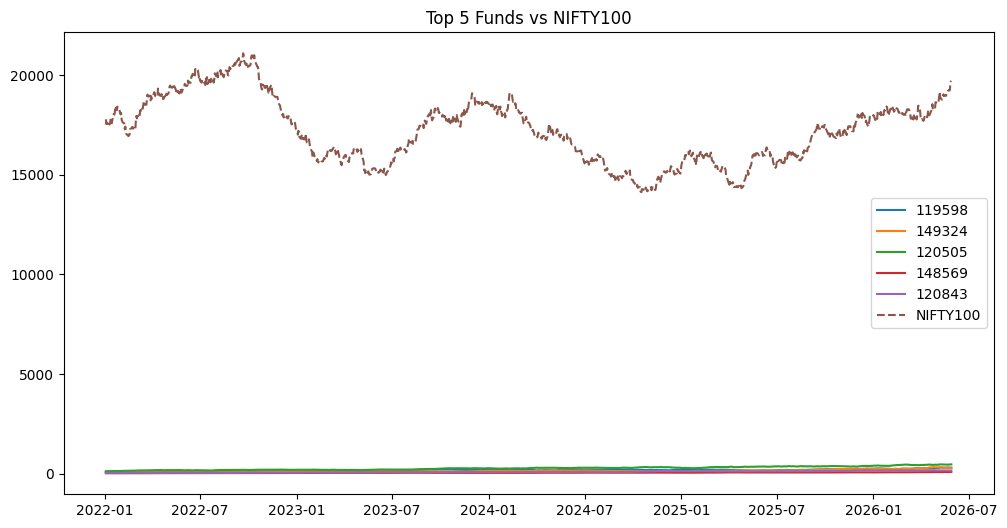

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for code in top5_codes:

    temp = top5_data[
        top5_data['amfi_code'] == code
    ]

    plt.plot(
        temp['date'],
        temp['nav'],
        label=str(code)
    )

plt.plot(
    nifty100['date'],
    nifty100['close_value'],
    label='NIFTY100',
    linestyle='--'
)

plt.title("Top 5 Funds vs NIFTY100")
plt.legend()

plt.savefig(
    "benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
import os

print(os.path.exists("benchmark_comparison.png"))

True


In [41]:
import os

files_to_check = [
    "fund_scorecard.csv",
    "alpha_beta.csv",
    "tracking_error.csv",
    "benchmark_comparison.png"
]

for f in files_to_check:
    print(f, "=>", os.path.exists(f))

fund_scorecard.csv => False
alpha_beta.csv => True
tracking_error.csv => True
benchmark_comparison.png => True


In [42]:
import os
print(os.getcwd())

C:\Users\shivj\OneDrive\Desktop\bluestock_mf_capstone\Notebook


In [43]:
nifty50 = benchmark[
    benchmark['index_name'] == 'NIFTY50'
].copy()

nifty50['date'] = pd.to_datetime(nifty50['date'])

nifty50 = nifty50.sort_values('date')

nifty50['nifty50_return'] = nifty50['close_value'].pct_change()

In [44]:
drawdown_details = []

for code in nav['amfi_code'].unique():

    df = nav[nav['amfi_code'] == code].copy()

    df['running_max'] = df['nav'].cummax()

    df['drawdown'] = (
        df['nav'] / df['running_max']
    ) - 1

    worst_idx = df['drawdown'].idxmin()

    worst_date = df.loc[worst_idx, 'date']

    max_dd = df.loc[worst_idx, 'drawdown']

    drawdown_details.append([
        code,
        max_dd,
        worst_date
    ])

drawdown_df = pd.DataFrame(
    drawdown_details,
    columns=[
        'amfi_code',
        'max_drawdown',
        'worst_drawdown_date'
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown,worst_drawdown_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [45]:
fund_master = pd.read_csv(
    r"C:\Users\shivj\OneDrive\Desktop\bluestock_mf_capstone\data\Raw\01_fund_master.csv"
)

print(fund_master.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [48]:
cagr_list = []

for code in nav['amfi_code'].unique():

    df = nav[nav['amfi_code'] == code].sort_values('date')

    start_nav = df.iloc[0]['nav']
    end_nav = df.iloc[-1]['nav']

    years = (
        (df.iloc[-1]['date'] - df.iloc[0]['date']).days
    ) / 365

    cagr = (end_nav / start_nav) ** (1 / years) - 1

    cagr_list.append([code, cagr])

cagr_df = pd.DataFrame(
    cagr_list,
    columns=['amfi_code', 'cagr']
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [49]:
print(fund_master.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [51]:
score_df = cagr_df.merge(
    alpha_beta_df,
    on='amfi_code'
)

score_df = score_df.merge(
    drawdown_df[['amfi_code','max_drawdown']],
    on='amfi_code'
)

score_df = score_df.merge(
    fund_master[['amfi_code','expense_ratio_pct']],
    on='amfi_code'
)

score_df.head()

,amfi_code,cagr,alpha,beta,max_drawdown,expense_ratio_pct
0,100016,0.026352,0.037476,-0.058268,-0.247344,1.55
1,100025,0.044551,0.042818,0.001158,-0.043083,0.56
2,100033,0.300997,0.271954,0.005104,-0.162172,1.38
3,101206,0.235205,0.213998,0.021086,-0.112916,1.60
4,101207,0.079331,0.108971,-0.065289,-0.354469,1.53


In [53]:
%whos DataFrame

Variable            Type         Data/Info
------------------------------------------
alpha_beta_df       DataFrame    Shape: (40, 3)
benchmark           DataFrame    Shape: (8050, 3)
cagr_df             DataFrame    Shape: (40, 2)
df                  DataFrame    Shape: (1150, 4)
drawdown_df         DataFrame    Shape: (40, 3)
fund_master         DataFrame    Shape: (40, 15)
merged              DataFrame    Shape: (45960, 5)
nav                 DataFrame    Shape: (46000, 4)
nifty100            DataFrame    Shape: (1150, 4)
nifty50             DataFrame    Shape: (1150, 4)
score_df            DataFrame    Shape: (40, 6)
temp                DataFrame    Shape: (1150, 4)
top5                DataFrame    Shape: (5, 3)
top5_data           DataFrame    Shape: (5750, 4)
tracking_error_df   DataFrame    Shape: (40, 2)


In [54]:
print(score_df.columns.tolist())

['amfi_code', 'cagr', 'alpha', 'beta', 'max_drawdown', 'expense_ratio_pct']


In [56]:
rf = 0.065

sharpe_list = []

for code in nav['amfi_code'].unique():

    df = nav[nav['amfi_code'] == code].copy()

    returns = df['daily_return'].dropna()

    mean_return = returns.mean() * 252

    std_return = returns.std() * np.sqrt(252)

    sharpe = (mean_return - rf) / std_return

    sharpe_list.append([code, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=['amfi_code', 'sharpe']
)

sharpe_df.head()

,amfi_code,sharpe
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [57]:
score_df = score_df.merge(
    sharpe_df,
    on='amfi_code'
)

score_df.head()

,amfi_code,cagr,alpha,beta,max_drawdown,expense_ratio_pct,sharpe
0,100016,0.026352,0.037476,-0.058268,-0.247344,1.55,-0.201517
1,100025,0.044551,0.042818,0.001158,-0.043083,0.56,-0.567095
2,100033,0.300997,0.271954,0.005104,-0.162172,1.38,1.093699
3,101206,0.235205,0.213998,0.021086,-0.112916,1.60,1.027213
4,101207,0.079331,0.108971,-0.065289,-0.354469,1.53,0.162661


In [58]:
score_df['score'] = (
    score_df['cagr'].rank(ascending=False) * 0.30
    +
    score_df['sharpe'].rank(ascending=False) * 0.25
    +
    score_df['alpha'].rank(ascending=False) * 0.20
    +
    score_df['expense_ratio_pct'].rank(ascending=True) * 0.15
    +
    score_df['max_drawdown'].rank(ascending=False) * 0.10
)

In [59]:
score_df = score_df.sort_values(
    'score',
    ascending=False
)

score_df.head(10)

,amfi_code,cagr,alpha,beta,max_drawdown,expense_ratio_pct,sharpe,score
7,102886,0.011709,0.028969,-0.042125,-0.280011,1.51,-0.205832,36.175
0,100016,0.026352,0.037476,-0.058268,-0.247344,1.55,-0.201517,35.850
17,119095,0.015205,0.048016,-0.066951,-0.516778,1.38,-0.075974,33.800
22,119599,0.020531,0.048824,0.062002,-0.525742,0.72,-0.057187,31.425
14,119092,0.063635,0.068995,0.009731,-0.144016,1.64,0.030785,31.075
29,120842,0.066968,0.078044,0.018057,-0.240035,1.56,0.076000,30.850
1,100025,0.044551,0.042818,0.001158,-0.043083,0.56,-0.567095,28.850
4,101207,0.079331,0.108971,-0.065289,-0.354469,1.53,0.162661,28.575
5,101208,0.065044,0.060861,0.000267,-0.001622,0.79,-0.815567,28.150
18,119120,0.058853,0.056209,-0.006414,-0.043287,0.77,-0.226575,28.100


In [60]:
score_df.to_csv(
    "fund_scorecard.csv",
    index=False
)

In [61]:
import os

print(os.path.exists("fund_scorecard.csv"))
print(os.path.exists("alpha_beta.csv"))
print(os.path.exists("benchmark_comparison.png"))

True
True
True
